<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/01_%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%97%90_%EA%BC%AD_%ED%95%84%EC%9A%94%ED%95%9C_%ED%8C%8C%EC%9D%B4%EC%8D%AC_%EA%B0%9C%EB%85%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

# sudo: switch user do : 관리자 권한
# apt-get install -y: 패키지를 자동으로 설치 (y 옵션으로 설치 확인 과정 생략)
# fonts-nanum*: 나눔 폰트 패키지들을 모두 설치 (*는 와일드카드)
# | tail -n 1: 설치 과정의 마지막 줄만 출력
# fc-cache: 폰트 캐시를 갱신하는 명령어
# -f: 강제로 캐시 재생성
# -v: 상세한 출력 표시
# matplotlib 라이브러리의 캐시 디렉토리를 완전히 삭제
# ~/.cache/matplotlib: 사용자 홈 디렉토리의 matplotlib 캐시 폴더
# -rf: 재귀적으로(-r) 강제로(-f) 삭제

0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direct

In [40]:
# 라이브러리

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import torch

# 폰트
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

1.2 컨테이너 타입 변수에 주의

- **컨테이너(Container)** : 여러 개의 객체를 한곳에 담을 수 있는 데이터 구조 >> 수납상자 ex) 리스트, 튜플, 딕셔너리

In [3]:
[1,2,3] + [1,2,3]

[1, 2, 3, 1, 2, 3]

In [5]:
np.array([1,2,3]) + np.array([1,2,3])

array([2, 4, 6])

In [4]:
# 넘파이 배열 x를 정의
x = np.array([5, 7, 9])

# 변수 y에 x를 대입
y = x

print(x)
print(y)

[5 7 9]
[5 7 9]


In [6]:
x[0]  # np.int64(5)

np.int64(5)

In [7]:
print(type(x))  # <class 'numpy.ndarray'>

<class 'numpy.ndarray'>


In [8]:
# x의 특정 요소를 변경
x[1] = -1

print(x)
print(y)  # y도 같이 변경되는 점 확

[ 5 -1  9]
[ 5 -1  9]


In [9]:
# copy 함수 사용
x = np.array([5, 7, 9])
y = x.copy()

x[1] = -1

print(x)
print(y)  # y 변화 없음

[ 5 -1  9]
[5 7 9]


In [10]:
import torch

torch.zeros(5)  # 0 값을 5개 가진 텐서 생성

tensor([0., 0., 0., 0., 0.])

In [11]:
print(torch.ones(5)) # 1 값을 5개 가진 텐서 생성
print(torch.ones(5).shape)  # torch.Size([5])

tensor([1., 1., 1., 1., 1.])
torch.Size([5])


In [12]:
x1 = torch.ones(6)
print(x1)

tensor([1., 1., 1., 1., 1., 1.])


In [13]:
# 텐서에서 넘파이 배열 생성
x2 = x1.data.numpy()
print(x2)

[1. 1. 1. 1. 1. 1.]


In [14]:
x1[1] = -1

print(x1)
print(x2) # 같이 변함

tensor([ 1., -1.,  1.,  1.,  1.,  1.])
[ 1. -1.  1.  1.  1.  1.]


In [15]:
x1 = torch.ones(5)
x2 = x1.data.numpy().copy()

x1[1] = -1

print(x1)
print(x2)   # x2 변화 없음

# numpy => CPU
# tensor => CPU, GPU (3차원 이상의 고차원을 해결하기 위한 것, numpy의 확장한 개념)
# scala => 0차원
# vector => 1차원

tensor([ 1., -1.,  1.,  1.,  1.])
[1. 1. 1. 1. 1.]


1.3 '합성 함수'를 파이썬으로 구현하기

In [33]:
def f(x):
  return (2 * x**2 + 2)

In [39]:
# 넘피아 배열로 x를 정의
x = np.arange(-2, 2.1, 0.25)
print(x)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]


In [35]:
#  f(x) 결과 y에 대입
y = f(x)
print(y)

[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]


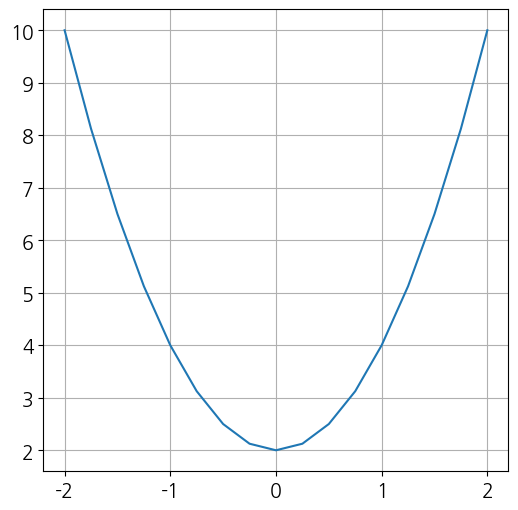

In [36]:
# 함수 그리기
plt.plot(x,y)
plt.show()

In [20]:
# 세 가지 기본 함수 정의
def f1(x):
  return x**2

def f2(x):
  return x*2

def f3(x):
  return x+2


x1 = f1(x)
x2 = f2(x1)
y = f3(x2)  # 딥러닝 모델의 순전파(forward) 과정

In [32]:
print(y)  # 위의 결과와 같음을 확인

0.7310585786300049


1.4 '미분'과 파이썬의 '수치 미분' 구현하기

In [27]:
# 함수 미분

def fdiff(f):
  def diff(x):
    h = 1e-6
    return ((f(x+h) - f(x-h)) / (2*h))

  return diff

In [28]:
# 수치 미분

diff = fdiff(f)
y_dash = diff(x)  # 미분 결과 대입
print(y_dash)

[-8. -7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.  8.]


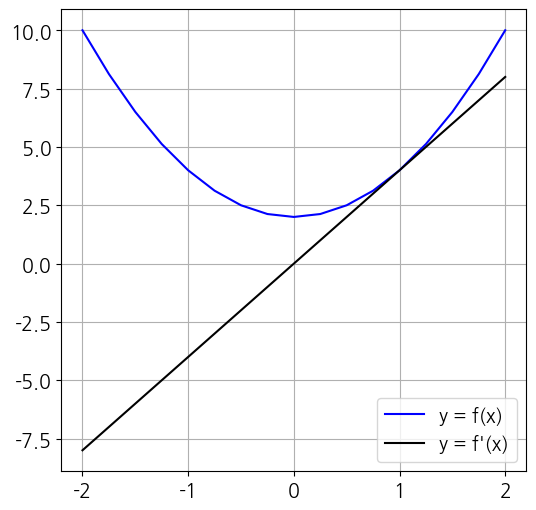

In [29]:
# 결과 그래프

plt.plot(x, y, label=r'y = f(x)', c='b')
plt.plot(x, y_dash, label=r"y = f'(x)", c='k')
plt.legend()
plt.show()

In [42]:
# 시그모이드 함수

def g(x):
  return 1 / (1 + np.exp(-x))

In [44]:
y = g(x)
print(y)

[0.1192 0.148  0.1824 0.2227 0.2689 0.3208 0.3775 0.4378 0.5    0.5622
 0.6225 0.6792 0.7311 0.7773 0.8176 0.852  0.8808]


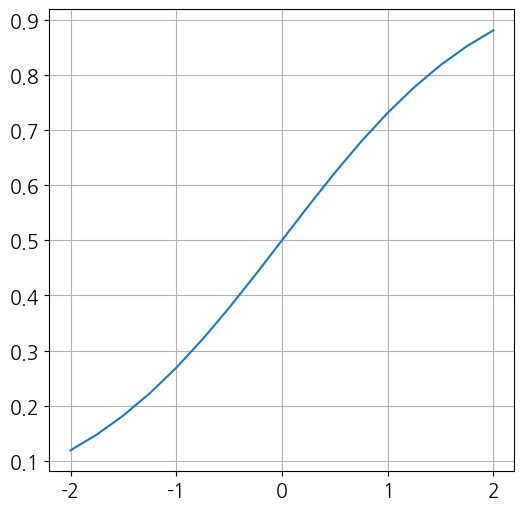

In [45]:
plt.plot(x,y)
plt.show()

In [47]:
# 시그모이드 함수 수치 미분

diff = fdiff(g)
y_dash = diff(x)
print(y_dash)

[0.105  0.1261 0.1491 0.1731 0.1966 0.2179 0.235  0.2461 0.25   0.2461
 0.235  0.2179 0.1966 0.1731 0.1491 0.1261 0.105 ]


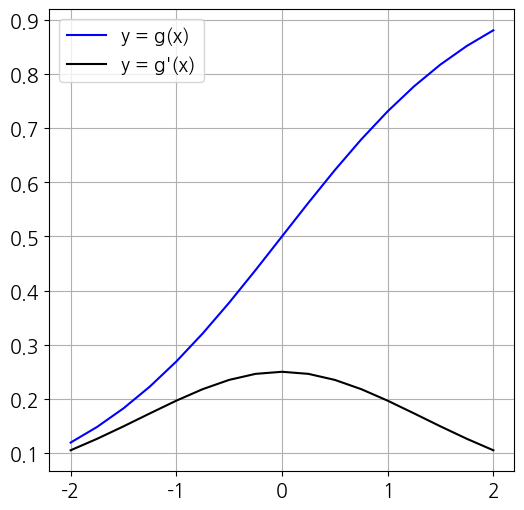

In [49]:
# 결과 그래프 출력

plt.plot(x, y, label=r'y = g(x)', c='b')
plt.plot(x, y_dash, label=r"y = g'(x)", c='k')
plt.legend()
plt.show()

In [ ]:
# eos